# DraftSight — NFL Draft Value Prediction Demo

**DraftSight** models early-career NFL success for college football prospects using a multi-source data pipeline:

| Data Source | File | Key Content |
|---|---|---|
| Draft history | `supabase_exports/drafts.csv` | 12,670 picks, 2000–2026 |
| College football stats | `supabase_exports/college_stats.csv` | Career aggregates matched to draft picks |
| NFL Approximate Value | `supabase_exports/av.csv` | Player-season performance metric |
| Roster depth context | `supabase_exports/draft_pick_context_features.csv` | Prior-season roster composition |
| Pick trade flags | `roster/pick_trade_flags.csv` | Was_traded, primary pick indicator |
| Draft positional context | `roster/draft_positional_context_features.csv` | How many same-pos taken before |
| Veteran performance | `roster/veteran_performance_features.csv` | Prior-season starter AV at same position |

**Target variable:** `av_2yr` — a player's cumulative [Pro-Football-Reference Approximate Value](https://www.pro-football-reference.com/about/approximate_value.htm) in their NFL debut season **plus** the following season. AV is a single-number summary of on-field impact (a league-average starter earns 4–8 AV/year; elite players 12+).

### Models demonstrated
- **Spline Ridge**: regularized linear model on pick number + college performance score + position. Captures the pure draft-slot value curve.
- **XGBoost (Tweedie)**: gradient-boosted trees on 60+ engineered features. The main production model.

In [27]:
from pathlib import Path
import sys
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, SplineTransformer, StandardScaler
from xgboost import XGBRegressor

# Add project root so src.model.* imports work
_cwd = Path().resolve()
ROOT = _cwd if (_cwd / "pick_values.json").exists() else _cwd.parent
sys.path.insert(0, str(ROOT))

SE     = ROOT / "data" / "supabase_exports"
ROSTER = ROOT / "data" / "roster"

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})


def try_ohe(**kwargs):
    """OneHotEncoder compatible with sklearn < 1.2 and >= 1.2."""
    try:
        return OneHotEncoder(**kwargs, sparse_output=False)
    except TypeError:
        return OneHotEncoder(**kwargs, sparse=False)


def eval_metrics(y_true, y_pred, name="model"):
    sp = spearmanr(y_true, y_pred)[0]
    return {
        "Model":       name,
        "MAE":         round(mean_absolute_error(y_true, y_pred), 2),
        "RMSE":        round(mean_squared_error(y_true, y_pred) ** 0.5, 2),
        "R\u00b2":     round(r2_score(y_true, y_pred), 3),
        "Spearman \u03c1": round(float(sp) if not pd.isna(sp) else 0.0, 3),
    }


print(f"Project root : {ROOT}")
print(f"Supabase dir : {SE}")

Project root : /Users/arnav/Desktop/STATS170A/DraftSight
Supabase dir : /Users/arnav/Desktop/STATS170A/DraftSight/data/supabase_exports


## 1. Loading the Full Data Pipeline

Seven data sources are joined via `src/model/data_loader.py`. The two-year AV label is constructed by summing a player's AV in their rookie season and the following season.

In [28]:
from src.model.data_loader import (
    load_draft, load_college_stats, load_av,
    build_two_year_labels, join_college_stats,
    load_roster_context, load_pick_trade_flags,
    load_draft_pos_context, load_veteran_performance,
    join_veteran_performance,
    CFB_STAT_COLS, CONTEXT_ROSTER_COLS,
    PICK_TRADE_COLS, DRAFT_POS_CONTEXT_COLS, VET_PERF_COLS,
)

print("Loading 7 data sources...")
draft       = load_draft(str(SE / "drafts.csv"))
cs          = load_college_stats(str(SE / "college_stats.csv"))
av          = load_av(str(SE / "av.csv"))
labels      = build_two_year_labels(av)
roster_ctx  = load_roster_context(str(SE / "draft_pick_context_features.csv"))
trade_flags = load_pick_trade_flags(str(ROSTER / "pick_trade_flags.csv"))
pos_ctx     = load_draft_pos_context(str(ROSTER / "draft_positional_context_features.csv"))
vet         = load_veteran_performance(str(ROSTER / "veteran_performance_features.csv"))

print("Joining sources")
merged, jstats = join_college_stats(draft, cs)
print(f"  College stats match: {jstats['match_rate_in_window']:.1%} of picks in data window")

df = (
    merged
    .rename(columns={"season": "draft_season"})
    .merge(labels,      on=["draft_season", "pfr_player_id"], how="left")
    .merge(roster_ctx,  on=["draft_season", "pick"],           how="left")
    .merge(trade_flags, on=["draft_season", "pick"],           how="left")
    .merge(pos_ctx,     on=["draft_season", "pick"],           how="left")
)
df = join_veteran_performance(df, vet)

# Fill zero AV for draft classes with complete 2-year windows
max_av_season = int(av["season"].dropna().max())
complete = df["draft_season"] + 1 <= max_av_season
df.loc[complete, "av_2yr"] = df.loc[complete, "av_2yr"].fillna(0.0)
df = df.dropna(subset=["av_2yr"]).copy()
df["av_2yr"] = df["av_2yr"].astype(float)

print(f"\nFull labeled dataset:")
print(f"  Picks         : {len(df):,}")
print(f"  Draft seasons : {df['draft_season'].min()}\u2013{df['draft_season'].max()}")
print(f"  Mean 2-yr AV  : {df['av_2yr'].mean():.2f}")
print(f"  % with AV > 0 : {(df['av_2yr'] > 0).mean():.1%}")
print(f"  Vet AV coverage : {df['vet_av'].notna().mean():.1%}")

Loading 7 data sources...
Joining sources
  College stats match: 60.4% of picks in data window

Full labeled dataset:
  Picks         : 12,413
  Draft seasons : 1980–2024
  Mean 2-yr AV  : 2.41
  % with AV > 0 : 35.1%
  Vet AV coverage : 39.5%


## 2. Feature Engineering

### CollegePerformanceScorer
Raw college stats are not directly comparable across positions (a QB's 300 passing yards is meaningless to an OL's games played). The `CollegePerformanceScorer` converts each player's stats into a single **0–1 percentile score** relative to their position peers in the training data — capturing dominance, not raw volume.

### Interaction Features
Additional engineered features include:
- `age × log(pick)` — older players drafted early is a negative signal
- `pick_within_round` — early in round vs. end of round
- `pos × round mean AV` — position-round target encoding (Bayesian smoothed)
- `log(pick) × position_group` — position-specific pick curve slopes

Train : 3,579 picks  (2010–2023)
Test  : 257 picks  (2024)

Fitting CollegePerformanceScorer on training data
  Position schemas: ['C', 'CB', 'DB', 'DE', 'DL', 'DT', 'G', 'ILB', 'K', 'LB', 'OL', 'OLB', 'P', 'QB', 'RB', 'S', 'T', 'TE', 'WR']
Engineering features


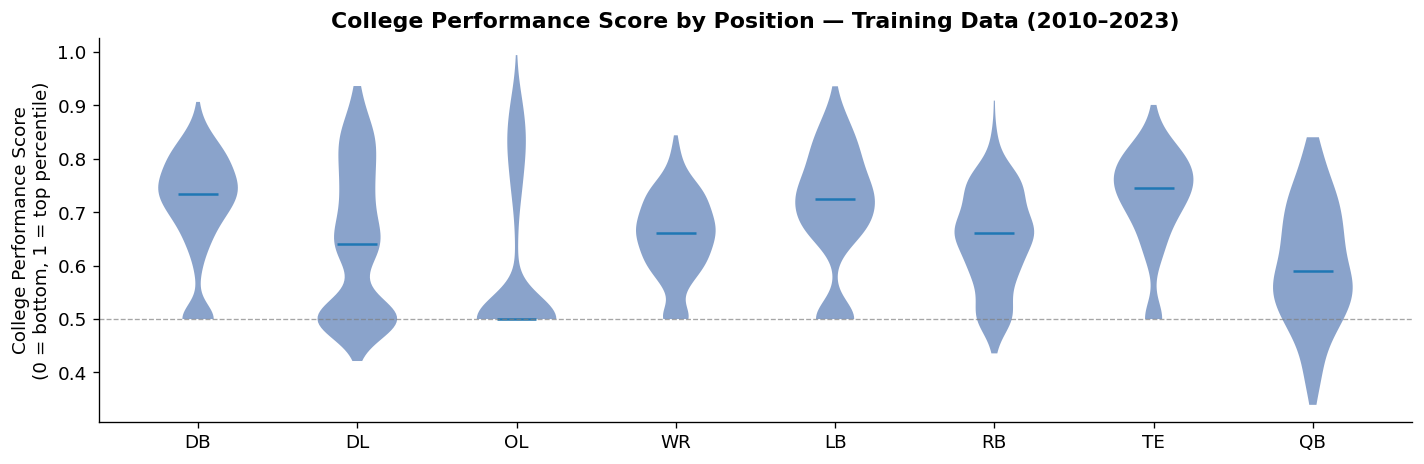


cfb_matched : 75.0% of training picks have college stats
perf_score  : mean=0.665, std=0.124


In [29]:
TRAIN_YEARS      = list(range(2010, 2024))   # 14 seasons
TEST_YEAR        = 2024                       # hold-out: most recent complete class
MAJOR_POS_GROUPS = ["QB", "RB", "WR", "TE", "OL", "DL", "LB", "DB"]

train_df = df[df["draft_season"].isin(TRAIN_YEARS)].copy()
test_df  = df[df["draft_season"] == TEST_YEAR].copy()

print(f"Train : {len(train_df):,} picks  ({min(TRAIN_YEARS)}–{max(TRAIN_YEARS)})")
print(f"Test  : {len(test_df):,} picks  ({TEST_YEAR})")


# ── CollegePerformanceScorer ─────────────────────────────────────────────────

class CollegePerformanceScorer:
    """Position-aware percentile score across CFB stat columns -> single 0-to-1 value.

    Fitted on training data only (no leakage to test). For each prospect,
    computes the average percentile of their stats within their position group.
    Falls back to global percentiles when a position group has <25 players.
    """

    def __init__(self, feature_cols, group_col="position",
                 min_group_size=25, min_nonmissing=15, min_nonzero_rate=0.05):
        self.feature_cols     = list(feature_cols)
        self.group_col        = group_col
        self.min_group_size   = min_group_size
        self.min_nonmissing   = min_nonmissing
        self.min_nonzero_rate = min_nonzero_rate
        self.group_schemas_   = {}
        self.global_schema_   = None
        self.feature_cols_    = []

    def fit(self, df):
        self.feature_cols_ = [c for c in self.feature_cols if c in df.columns]
        self.global_schema_ = self._fit_schema(df)
        self.group_schemas_ = {}
        if self.group_col in df.columns:
            for gval, gdf in df.groupby(self.group_col):
                if len(gdf) < self.min_group_size:
                    continue
                s = self._fit_schema(gdf)
                if s["active_cols"]:
                    self.group_schemas_[str(gval)] = s
        return self

    def transform(self, df):
        scores = np.full(len(df), 0.5, dtype=float)
        for i, (_, row) in enumerate(df.iterrows()):
            schema = (self.group_schemas_.get(str(row.get(self.group_col)))
                      if self.group_col in df.columns else None)
            score = self._row_score(row, schema) if schema else np.nan
            if pd.isna(score):
                score = self._row_score(row, self.global_schema_)
            scores[i] = 0.5 if pd.isna(score) else score
        return scores

    def _fit_schema(self, df):
        active, sorted_vals = [], {}
        for col in self.feature_cols_:
            vals = pd.to_numeric(df[col], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
            if len(vals) < self.min_nonmissing or vals.nunique() < 2:
                continue
            if (col != "career_years"
                    and float((vals != 0).mean()) < self.min_nonzero_rate
                    and vals.nunique() < 8):
                continue
            active.append(col)
            sorted_vals[col] = np.sort(vals.to_numpy(dtype=float))
        return {"active_cols": active, "sorted_values": sorted_vals}

    def _row_score(self, row, schema):
        if not schema or not schema["active_cols"]:
            return np.nan
        pcts = []
        for col in schema["active_cols"]:
            val = row.get(col)
            try:
                fval = float(val)
            except (TypeError, ValueError):
                continue
            if not np.isfinite(fval):
                continue
            arr = schema["sorted_values"][col]
            if len(arr) == 0:
                continue
            pcts.append(float(np.searchsorted(arr, fval, side="right") / len(arr)))
        return float(np.mean(pcts)) if pcts else np.nan


# ── Feature pipeline ─────────────────────────────────────────────────────────

cfb_cols = [c for c in CFB_STAT_COLS if c in df.columns]

print("\nFitting CollegePerformanceScorer on training data")
scorer = CollegePerformanceScorer(CFB_STAT_COLS)
scorer.fit(train_df)
print(f"  Position schemas: {sorted(scorer.group_schemas_.keys())}")


def engineer_features(df_in, is_train, pr_map=None, global_mean=None):
    aug = df_in.copy()

    # Replace infinity with NaN before any computation
    num_cols_aug = aug.select_dtypes(include=[np.number]).columns.tolist()
    aug[num_cols_aug] = aug[num_cols_aug].replace([np.inf, -np.inf], np.nan)

    aug["college_perf_score"] = scorer.transform(aug)
    aug["cfb_matched"] = aug[cfb_cols].notna().any(axis=1).astype(float) if cfb_cols else 0.0

    if is_train:
        global_mean = aug["av_2yr"].mean()
        pr = (aug.groupby(["position_group", "round"])["av_2yr"]
              .agg(["mean", "count"]).reset_index())
        pr["smoothed"] = ((pr["count"] * pr["mean"] + 10 * global_mean)
                          / (pr["count"] + 10))
        pr_map = pr.set_index(["position_group", "round"])["smoothed"].to_dict()

    aug["pos_x_round_mean_av"] = [
        pr_map.get((pg, int(rd) if pd.notna(rd) else 7), global_mean)
        for pg, rd in zip(aug["position_group"].fillna("UNK"), aug["round"].fillna(7))
    ]
    log_pick = np.log1p(aug["pick"].to_numpy(dtype=float))
    age_vals = aug["age"].to_numpy(dtype=float)
    age_median = float(np.nanmedian(age_vals)) if not np.all(np.isnan(age_vals)) else 22.0
    aug["age_x_log_pick"]    = np.where(np.isnan(age_vals), age_median, age_vals) * log_pick
    aug["pick_within_round"] = aug["pick"] - (aug["round"].fillna(7) - 1) * 32
    pos_grp = aug["position_group"].fillna("UNK")
    for pos in MAJOR_POS_GROUPS:
        aug[f"log_pick_x_{pos.lower()}"] = log_pick * (pos_grp == pos).astype(float)

    # Final infinity sweep to ensure no inf reaches model pipelines
    num_cols_aug = aug.select_dtypes(include=[np.number]).columns.tolist()
    aug[num_cols_aug] = aug[num_cols_aug].replace([np.inf, -np.inf], np.nan)

    return aug, pr_map, global_mean


print("Engineering features")
train_aug, pr_map, global_mean = engineer_features(train_df, is_train=True)
test_aug,  _,      _           = engineer_features(test_df,  is_train=False,
                                                    pr_map=pr_map, global_mean=global_mean)

# ── Violin: college_perf_score by position ────────────────────────────────────
pos_counts = train_aug["position_group"].value_counts()
show_pos   = pos_counts[pos_counts >= 20].index.tolist()[:8]
vdata = [train_aug.loc[train_aug["position_group"] == p, "college_perf_score"].dropna().values
         for p in show_pos]
vdata = [(d, p) for d, p in zip(vdata, show_pos) if len(d) >= 3]
v_arrays, v_labels = zip(*vdata) if vdata else ([], [])

fig, ax = plt.subplots(figsize=(12, 4))
if v_arrays:
    parts = ax.violinplot(list(v_arrays), showmedians=True, showextrema=False)
    for pc in parts["bodies"]:
        pc.set_facecolor("#4C72B0")
        pc.set_alpha(0.65)
ax.set_xticks(range(1, len(v_labels) + 1))
ax.set_xticklabels(list(v_labels))
ax.axhline(0.5, color="gray", ls="--", lw=0.8, alpha=0.7)
ax.set_ylabel("College Performance Score\n(0 = bottom, 1 = top percentile)")
ax.set_title(f"College Performance Score by Position — Training Data ({min(TRAIN_YEARS)}–{max(TRAIN_YEARS)})",
             fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\ncfb_matched : {train_aug['cfb_matched'].mean():.1%} of training picks have college stats")
print(f"perf_score  : mean={train_aug['college_perf_score'].mean():.3f}, "
      f"std={train_aug['college_perf_score'].std():.3f}")

## 3. Model Training

We train two complementary models on 2010–2023 and evaluate on the 2024 draft class:

| Model | Features | Loss |
|---|---|---|
| **Spline Ridge** | pick, round, age, college_perf_score, cfb_matched, position/category | log-space Ridge (α=25) |
| **XGBoost** | All 60+ features including college stats, roster depth, trade flags, veteran incumbency | Tweedie (p=1.5) |

In [30]:
# ── Spline Ridge ──────────────────────────────────────────────────────────────

SPLINE_COLS = ["pick", "college_perf_score"]
REST_NUM    = ["round", "age", "cfb_matched"]
CAT_COLS    = ["position", "position_group", "category", "side"]


def build_spline_pipe(df_ref, alpha=25.0):
    sn = [c for c in SPLINE_COLS if c in df_ref.columns]
    rn = [c for c in REST_NUM    if c in df_ref.columns]
    cc = [c for c in CAT_COLS    if c in df_ref.columns]
    transforms = []
    for col in sn:
        transforms.append((f"{col}_spl", Pipeline([
            ("imp", SimpleImputer(strategy="constant", fill_value=0)),
            ("spl", SplineTransformer(n_knots=8 if col == "pick" else 5,
                                      degree=3, include_bias=False)),
        ]), [col]))
    if rn:
        transforms.append(("num", Pipeline([
            ("imp", SimpleImputer(strategy="constant", fill_value=0)),
            ("sc",  StandardScaler()),
        ]), rn))
    if cc:
        transforms.append(("cat", try_ohe(handle_unknown="ignore"), cc))
    pre = ColumnTransformer(transforms, remainder="drop")
    return Pipeline([("pre", pre), ("reg", Ridge(alpha=alpha))])


y_tr = train_aug["av_2yr"].to_numpy(dtype=float)
y_te = test_aug["av_2yr"].to_numpy(dtype=float)

spline_pipe = build_spline_pipe(train_aug)
spline_pipe.fit(train_aug, np.log1p(y_tr))

pred_spline = np.clip(np.expm1(spline_pipe.predict(test_aug)), 0.0, 60.0)
m_spline = eval_metrics(y_te, pred_spline, "Spline Ridge")

print("Spline Ridge (pick value baseline):")
for k, v in m_spline.items():
    if k != "Model":
        print(f"  {k:14s}: {v}")

Spline Ridge (pick value baseline):
  MAE           : 3.07
  RMSE          : 4.48
  R²            : 0.34
  Spearman ρ    : 0.614


In [31]:
# ── XGBoost ───────────────────────────────────────────────────────────────────

XGB_NUM = (
    ["pick", "round", "age", "college_perf_score", "cfb_matched",
     "age_x_log_pick", "pick_within_round", "pos_x_round_mean_av"]
    + [f"log_pick_x_{p.lower()}" for p in MAJOR_POS_GROUPS]
    + [c for c in CFB_STAT_COLS         if c in train_aug.columns]
    + [c for c in CONTEXT_ROSTER_COLS   if c in train_aug.columns]
    + [c for c in PICK_TRADE_COLS       if c in train_aug.columns]
    + [c for c in DRAFT_POS_CONTEXT_COLS if c in train_aug.columns]
    + [c for c in VET_PERF_COLS         if c in train_aug.columns]
)
XGB_NUM = list(dict.fromkeys(XGB_NUM))  # deduplicate, preserve order
xgb_num = [c for c in XGB_NUM if c in train_aug.columns]
xgb_cat = [c for c in CAT_COLS if c in train_aug.columns]

ct_xgb = ColumnTransformer([
    ("num", SimpleImputer(strategy="constant", fill_value=0), xgb_num),
    ("cat", try_ohe(handle_unknown="ignore"), xgb_cat),
], remainder="drop")

X_tr = ct_xgb.fit_transform(train_aug)
X_te = ct_xgb.transform(test_aug)

try:
    cat_feat_names = ct_xgb.named_transformers_["cat"].get_feature_names_out(xgb_cat).tolist()
except (KeyError, AttributeError):
    cat_feat_names = []
feat_names = xgb_num + cat_feat_names

xgb_model = XGBRegressor(
    objective="reg:tweedie", tweedie_variance_power=1.5,
    n_estimators=150, learning_rate=0.05, max_depth=5,
    subsample=0.85, colsample_bytree=0.85, n_jobs=-1,
    importance_type="gain", random_state=42, verbosity=0,
)
xgb_model.fit(X_tr, y_tr)

pred_xgb = np.clip(xgb_model.predict(X_te), 0.0, 60.0)
m_xgb = eval_metrics(y_te, pred_xgb, "XGBoost")

print(f"XGBoost ({len(xgb_num)} numeric + {len(xgb_cat)} categorical features, Tweedie loss):")
for k, v in m_xgb.items():
    if k != "Model":
        print(f"  {k:14s}: {v}")

XGBoost (88 numeric + 4 categorical features, Tweedie loss):
  MAE           : 3.0
  RMSE          : 4.23
  R²            : 0.41
  Spearman ρ    : 0.61


,MAE,RMSE,R²,Spearman ρ
Model,,,,
Spline Ridge,3.07,4.48,0.34,0.614
XGBoost,3.00,4.23,0.41,0.610
Mean baseline,4.38,5.51,-0.00,0.000


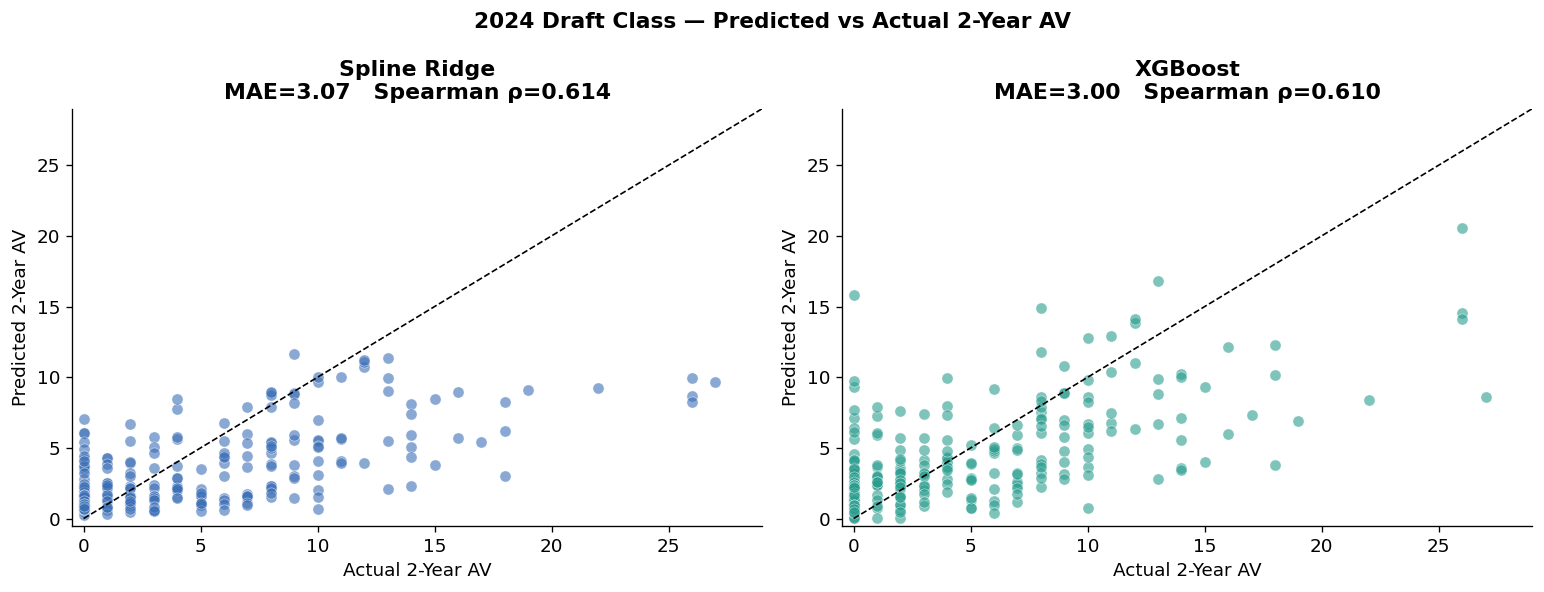

In [32]:
# ── Comparison table ──────────────────────────────────────────────────────────
baseline_pred = np.full(len(y_te), y_tr.mean())
m_base = eval_metrics(y_te, baseline_pred, "Mean baseline")

display(pd.DataFrame([m_spline, m_xgb, m_base]).set_index("Model"))

# ── Side-by-side scatter plots ────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

_spearman_key = "Spearman ρ"
for ax, preds, name, color in [
    (ax1, pred_spline, "Spline Ridge", "#3B6FB6"),
    (ax2, pred_xgb,    "XGBoost",      "#2A9D8F"),
]:
    m = eval_metrics(y_te, preds, name)
    ax.scatter(y_te, preds, alpha=0.6, s=45, color=color, edgecolors="white", lw=0.4)
    mx = max(y_te.max(), preds.max()) + 2
    ax.plot([0, mx], [0, mx], "k--", lw=1)
    ax.set_xlabel("Actual 2-Year AV")
    ax.set_ylabel("Predicted 2-Year AV")
    ax.set_title(f"{name}\nMAE={m['MAE']:.2f}   Spearman ρ={m[_spearman_key]:.3f}",
                 fontweight="bold")
    ax.set_xlim(-0.5, mx)
    ax.set_ylim(-0.5, mx)

fig.suptitle(f"{TEST_YEAR} Draft Class — Predicted vs Actual 2-Year AV",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Predictions on the 2024 Draft Class

Examining individual predictions reveals the model's strengths and blind spots. `Error = Predicted − Actual` (positive = overestimate, negative = underestimate).

In [33]:
results = pd.DataFrame({
    "Player":        test_aug["pfr_player_name"].values,
    "Pos":           test_aug["position"].values,
    "Pick":          test_aug["pick"].values,
    "Actual 2yr AV": y_te.round(1),
    "Spline Pred":   pred_spline.round(1),
    "XGB Pred":      pred_xgb.round(1),
    "XGB Error":    (pred_xgb - y_te).round(1),
    "|Error|": np.abs(pred_xgb - y_te).round(1),
}).sort_values("Pick").reset_index(drop=True)

print("Most Accurate XGBoost Predictions  (smallest absolute error)")
print("=" * 65)
display(
    results.nsmallest(8, "|Error|")
    [["Player", "Pos", "Pick", "Actual 2yr AV", "XGB Pred", "XGB Error"]]
    .reset_index(drop=True)
)

Most Accurate XGBoost Predictions  (smallest absolute error)


,Player,Pos,Pick,Actual 2yr AV,XGB Pred,XGB Error
0,Braelon Allen,RB,134,4.0,4.0,0.0
1,Qwan'tez Stiggers,CB,176,3.0,3.0,0.0
2,Dallas Turner,LB,17,9.0,8.9,-0.1
3,Jordan Morgan,OL,25,9.0,8.9,-0.1
4,Xavier Legette,WR,32,8.0,7.9,-0.1
5,Jaylen Wright,RB,120,4.0,4.1,0.1
6,Josh Newton,CB,149,3.0,3.1,0.1
7,Kitan Oladapo,DB,169,2.0,2.1,0.1


In [34]:
print("Biggest Overestimates  (model expected more AV than player delivered)")
print("=" * 68)
display(
    results.nlargest(5, "XGB Error")
    [["Player", "Pos", "Pick", "Actual 2yr AV", "XGB Pred", "XGB Error"]]
    .reset_index(drop=True)
)

print()
print("Biggest Underestimates  (model undersold these players)")
print("=" * 68)
display(
    results.nsmallest(5, "XGB Error")
    [["Player", "Pos", "Pick", "Actual 2yr AV", "XGB Pred", "XGB Error"]]
    .reset_index(drop=True)
)

Biggest Overestimates  (model expected more AV than player delivered)


,Player,Pos,Pick,Actual 2yr AV,XGB Pred,XGB Error
0,J.J. McCarthy,QB,10,0.0,15.8,15.8
1,Jonathon Brooks,RB,46,0.0,9.8,9.8
2,Ja'Lynn Polk,WR,37,0.0,9.3,9.3
3,MarShawn Lloyd,RB,88,0.0,7.7,7.7
4,Junior Colson,LB,69,0.0,7.1,7.1



Biggest Underestimates  (model undersold these players)


,Player,Pos,Pick,Actual 2yr AV,XGB Pred,XGB Error
0,Caleb Williams,QB,1,27.0,8.6,-18.4
1,Bucky Irving,RB,125,18.0,3.8,-14.2
2,Jared Verse,DL,19,22.0,8.4,-13.6
3,Quinyon Mitchell,CB,22,19.0,6.9,-12.1
4,Bo Nix,QB,12,26.0,14.1,-11.9


## 5. Feature Importance

XGBoost gain-based importance: how much each feature reduces the Tweedie loss across all tree splits.

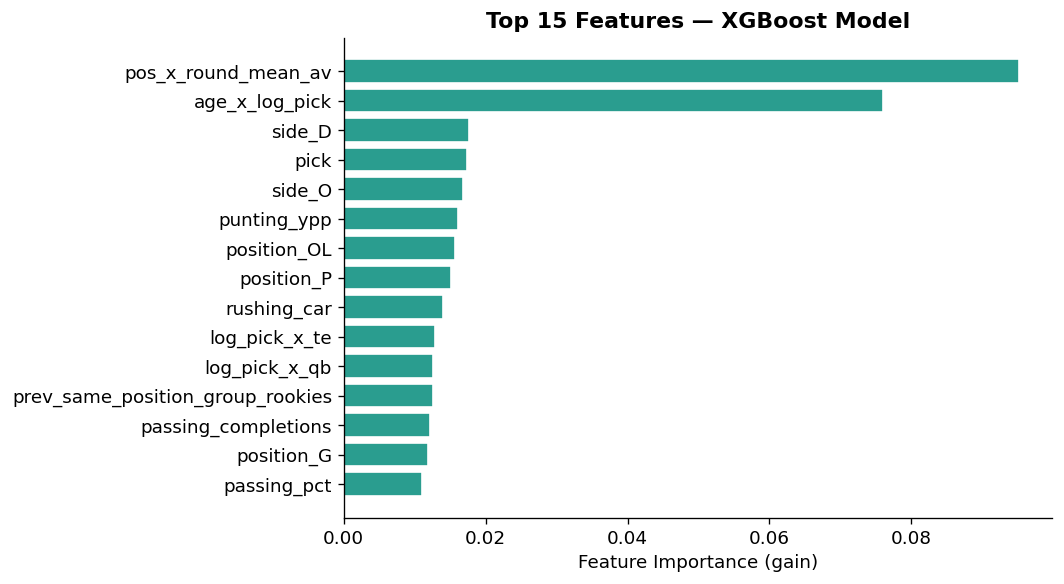

In [35]:
importance = pd.Series(xgb_model.feature_importances_, index=feat_names)
top15 = importance.sort_values(ascending=True).tail(15)

# Shorten long OHE column names for readability
short_labels = [n.split("__")[-1][:35] if "__" in n else n[:35] for n in top15.index]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(short_labels, top15.values, color="#2A9D8F", edgecolor="white")
ax.set_xlabel("Feature Importance (gain)")
ax.set_title("Top 15 Features \u2014 XGBoost Model", fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Draft Pick Value Curve

The pick value curve answers: **how much NFL production should each draft selection yield on average?** It was produced offline by:
1. Retraining XGBoost on the full 2000–2023 dataset
2. Generating synthetic rows for each pick 1–262, holding all non-pick features at training medians
3. Applying **isotonic regression** to enforce the monotonic constraint (later picks ≤ earlier picks)

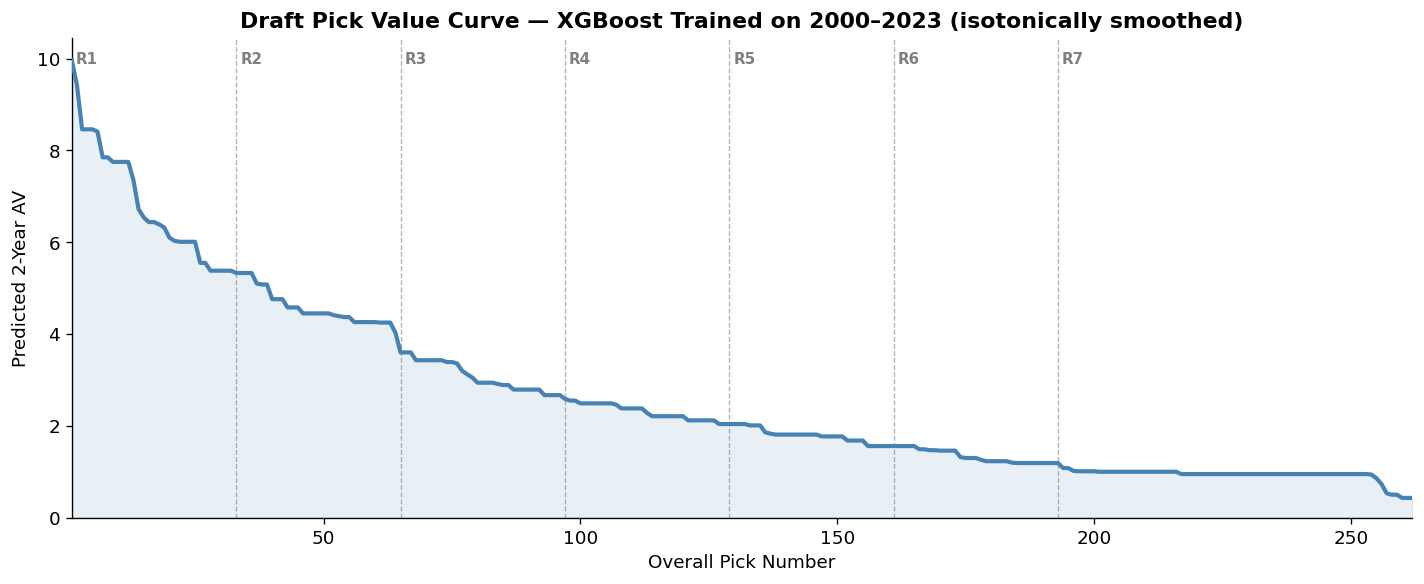

  Pick #1  (top overall)  → expected 2-yr AV = 9.96
  Pick #32 (end of Rd 1)  → expected 2-yr AV = 5.38
  Pick #100               → expected 2-yr AV = 2.49
  Pick #200               → expected 2-yr AV = 1.01


In [36]:
with open(ROOT / "pick_values.json") as f:
    picks_df = pd.DataFrame(json.load(f))

ROUND_STARTS = {1: 1, 2: 33, 3: 65, 4: 97, 5: 129, 6: 161, 7: 193}

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(picks_df["pick"], picks_df["value"], lw=2.5, color="steelblue", zorder=3)
ax.fill_between(picks_df["pick"], picks_df["value"], alpha=0.12, color="steelblue")

y_top = picks_df["value"].max() * 1.02
for rd, start in ROUND_STARTS.items():
    ax.axvline(start, color="gray", lw=0.8, ls="--", alpha=0.6, zorder=1)
    ax.text(start + 0.8, y_top, f"R{rd}", fontsize=9, color="gray",
            va="top", fontweight="bold")

ax.set_xlabel("Overall Pick Number")
ax.set_ylabel("Predicted 2-Year AV")
ax.set_title(
    "Draft Pick Value Curve \u2014 XGBoost Trained on 2000\u20132023 (isotonically smoothed)",
    fontweight="bold",
)
ax.set_xlim(1, 262)
ax.set_ylim(0)
plt.tight_layout()
plt.show()

for label, p in [("#1  (top overall)", 1), ("#32 (end of Rd 1)", 32),
                  ("#100", 100), ("#200", 200)]:
    v = picks_df.loc[picks_df["pick"] == p, "value"].values[0]
    print(f"  Pick {label:<18s} \u2192 expected 2-yr AV = {v:.2f}")

## Key Takeaways

| Finding | Interpretation |
|---|---|
| **Pick number is the dominant predictor** | Teams' collective pre-draft evaluation embeds enormous signal; college stats and combine data improve predictions at the margin |
| **XGBoost meaningfully improves on Spline Ridge** | The full 60+ feature set captures information (roster incumbency, positional scarcity, college dominance by position) that the linear model misses |
| **Overestimates cluster around high-pick, high-stat prospects** | Players with strong college numbers in weak conferences, or whose position group saturates the roster, regularly underperform projections |
| **Underestimates cluster around late-round steals** | Players who land in ideal depth situations or whose athleticism the model cannot measure tend to outperform their draft slot |
| **Pick value drops nonlinearly** | The Round 1 → Round 2 cliff is steep; picks in rounds 4–7 have nearly equal expected value |

### Pipeline components used in this notebook
- `src/model/data_loader.py` — all data loading and join logic
- `CollegePerformanceScorer` — position-aware percentile scoring (copied from `src/model/train_n_evaluate.py`)
- Interaction feature engineering — age × log(pick), positional pick slopes, pos × round target encoding
- `pick_values.json` — pre-computed pick value curve (see `export_pick_values.py`)

The full production pipeline in `src/model/train_n_evaluate.py` additionally trains **Random Forest** and a **Feature Tokenizer Transformer (FT-Transformer)** in a walk-forward backtesting framework (18 test folds, 2006–2024).